# Exercícios 1 a 4 — Diagnóstico de Overfitting, Funções de Ativação e Otimizadores

**Objetivo:** executar uma sequência de experimentos com MLP para analisar overfitting, comparar arquiteturas, testar funções de ativação e medir o efeito dos otimizadores.

## O que será feito
- Exercício 1: comparação entre MLP pequena, média e grande.
- Exercício 2: comparação entre ReLU, Tanh e Sigmoid.
- Exercício 3: comparação entre SGD e Adam.
- Exercício 4: relatório curto com os resultados experimentais.

## Dataset
- Arquivo: `BEED_Data.csv`
- Variável alvo: `y`
- Features: `X1` a `X16`

In [3]:
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA compilado: {torch.version.cuda}")
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"Usando dispositivo: {device}")

PyTorch: 2.6.0+cu124
CUDA compilado: 12.4
CUDA disponível: True
Usando dispositivo: cuda


## 1. Carregamento e preparação dos dados

O problema é de classificação multiclasse com 4 classes balanceadas. O conjunto será dividido em treino e validação com estratificação, e as features serão padronizadas para melhorar a estabilidade do treinamento.

In [4]:
data_path = Path(r"../datasets/BEED_Data.csv")
df = pd.read_csv(data_path)

X = df.drop(columns=["y"]).values.astype(np.float32)
y = df["y"].values.astype(np.int64)

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=SEED,
    stratify=y,
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_val = scaler.transform(X_val).astype(np.float32)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False)

print("Dataset:", df.shape)
print("Treino:", X_train_t.shape, y_train_t.shape)
print("Validação:", X_val_t.shape, y_val_t.shape)
print("Classes:")
print(df["y"].value_counts().sort_index())

Dataset: (8000, 17)
Treino: torch.Size([6000, 16]) torch.Size([6000])
Validação: torch.Size([2000, 16]) torch.Size([2000])
Classes:
y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


## 2. Funções auxiliares

O notebook usa uma única rotina de treino para todos os experimentos, o que facilita a comparação justa entre os modelos.

In [5]:
ACTIVATIONS = {
    "relu": nn.ReLU,
    "tanh": nn.Tanh,
    "sigmoid": nn.Sigmoid,
}


def build_mlp(input_dim, hidden_layers, output_dim=4, activation="relu"):
    activation_cls = ACTIVATIONS[activation]
    layers = []
    previous_dim = input_dim
    for hidden_dim in hidden_layers:
        layers.append(nn.Linear(previous_dim, hidden_dim))
        layers.append(activation_cls())
        previous_dim = hidden_dim
    layers.append(nn.Linear(previous_dim, output_dim))
    return nn.Sequential(*layers)


class MLPClassifier(nn.Module):
    def __init__(self, input_dim, hidden_layers, activation="relu"):
        super().__init__()
        self.net = build_mlp(input_dim, hidden_layers, activation=activation)

    def forward(self, x):
        return self.net(x)


def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * xb.size(0)
            total_correct += (logits.argmax(dim=1) == yb).sum().item()
            total_samples += xb.size(0)

    return total_loss / total_samples, total_correct / total_samples


def train_model(model, train_loader, val_loader, criterion, optimizer, epochs=80):
    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }
    start_time = time.perf_counter()

    for _ in range(epochs):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

    history["elapsed_seconds"] = time.perf_counter() - start_time
    return history


def summarize_history(name, history):
    return {
        "modelo": name,
        "train_acc_final": history["train_acc"][-1],
        "val_acc_final": history["val_acc"][-1],
        "train_loss_final": history["train_loss"][-1],
        "val_loss_final": history["val_loss"][-1],
        "gap_acc": history["train_acc"][-1] - history["val_acc"][-1],
        "tempo_s": history["elapsed_seconds"],
    }


def plot_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Época")
    plt.ylabel("Loss")
    plt.title(f"{title} - Loss")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Época")
    plt.ylabel("Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()


def run_experiment(model_name, hidden_layers, activation="relu", optimizer_name="adam", lr=1e-3, weight_decay=0.0, epochs=80):
    torch.manual_seed(SEED)
    model = MLPClassifier(X_train_t.shape[1], hidden_layers, activation=activation).to(device)

    if optimizer_name.lower() == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    elif optimizer_name.lower() == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=weight_decay)
    else:
        raise ValueError(f"Otimizador não suportado: {optimizer_name}")

    criterion = nn.CrossEntropyLoss()
    history = train_model(model, train_loader, val_loader, criterion, optimizer, epochs=epochs)
    summary = summarize_history(model_name, history)
    return model, history, summary

## 3. Exercício 1 — Diagnóstico de Overfitting

três arquiteturas com a mesma função de ativação e o mesmo otimizador.

MLP pequena: 16 → 32
- 16 = número de neurônios na camada de entrada (features do dataset)
- 32 = número de neurônios na camada oculta

MLP média: 16 → 64 → 32
- 16 = entrada
- 64 = 1ª camada oculta
- 32 = 2ª camada oculta

MLP grande: 16 → 128 → 64 → 32
- 16 = entrada
- 128 = 1ª camada oculta
- 64 = 2ª camada oculta
- 32 = 3ª camada oculta

In [6]:
experiments_overfitting = {
    "MLP pequena": [32],
    "MLP média": [64, 32],
    "MLP grande": [128, 64, 32],
}

overfit_histories = {}
overfit_rows = []

for name, hidden_layers in experiments_overfitting.items():
    _, history, summary = run_experiment(
        model_name=name,
        hidden_layers=hidden_layers,
        activation="relu",
        optimizer_name="adam",
        lr=1e-3,
        weight_decay=0.0,
        epochs=80,
    )
    overfit_histories[name] = history
    overfit_rows.append(summary)
    plot_history(history, name)

results_overfitting = pd.DataFrame(overfit_rows).sort_values("val_acc_final", ascending=False)
results_overfitting

KeyboardInterrupt: 

## 4. Exercício 2 — Funções de Ativação

mesma arquitetura e trocando apenas a ativação:
- ReLU
- Tanh
- Sigmoid

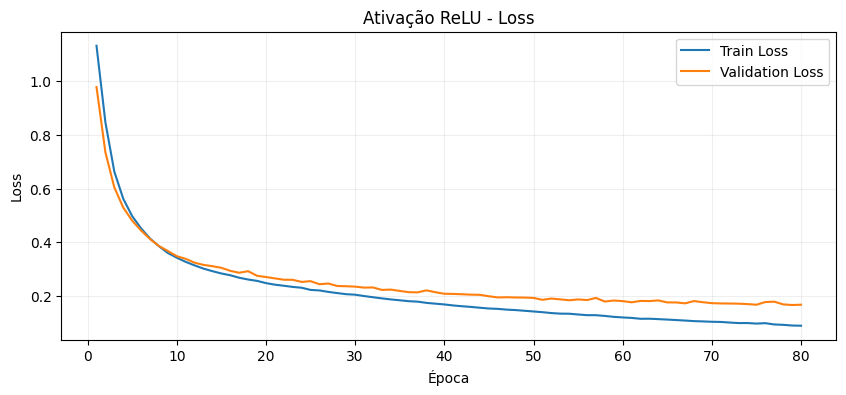

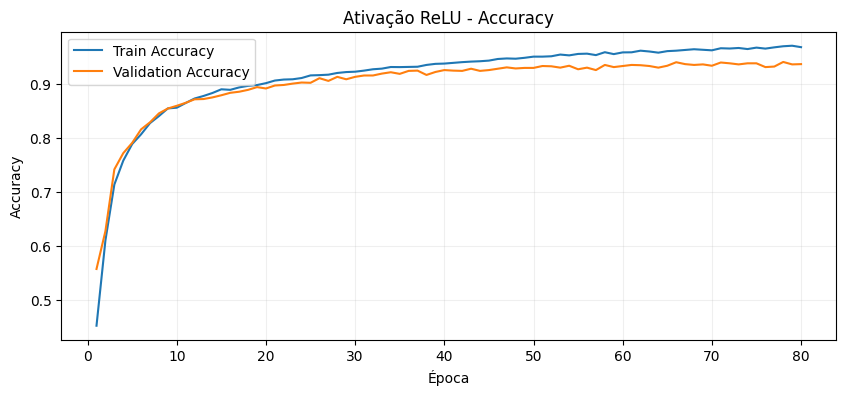

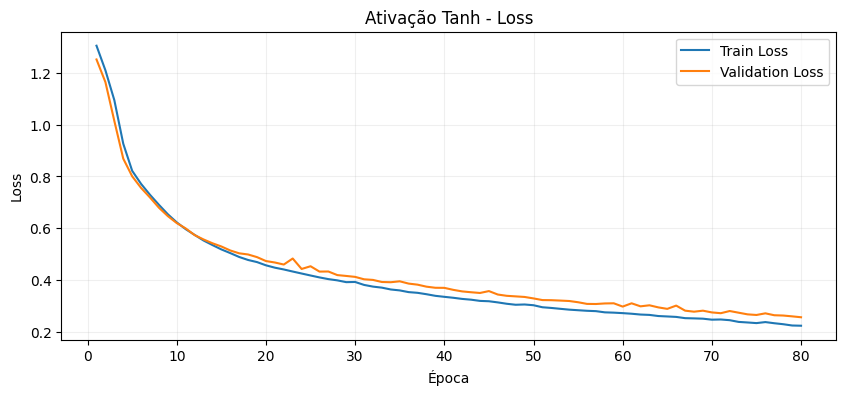

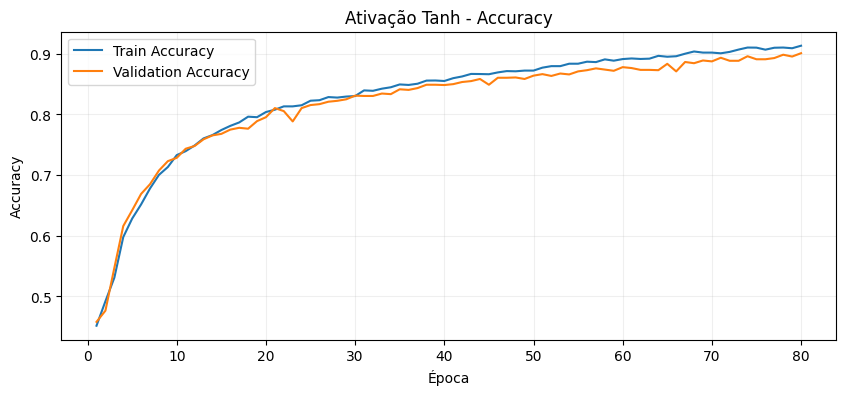

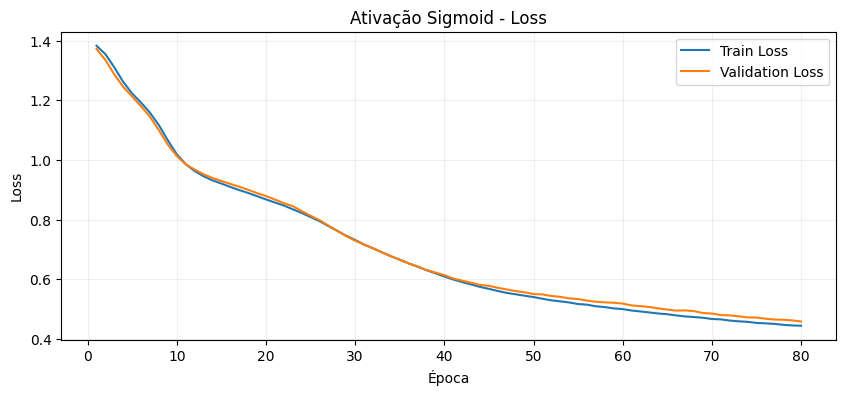

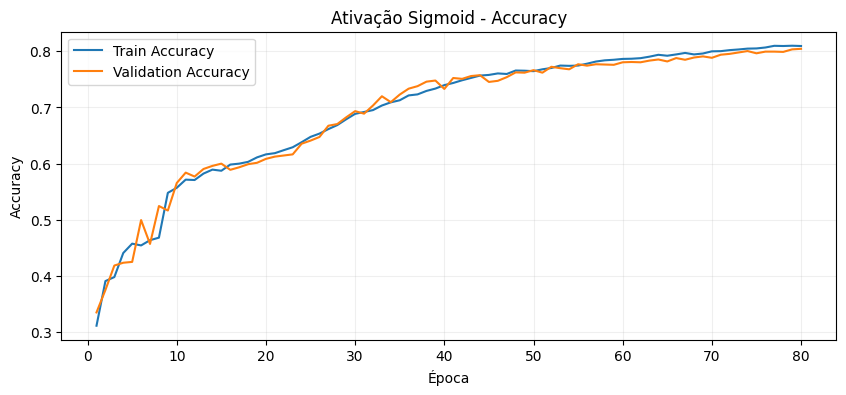

,modelo,train_acc_final,val_acc_final,train_loss_final,val_loss_final,gap_acc,tempo_s
0,MLP média - ReLU,0.967833,0.9365,0.090065,0.168194,0.031333,21.657374
1,MLP média - Tanh,0.913333,0.9010,0.222796,0.255536,0.012333,21.837539
2,MLP média - Sigmoid,0.809500,0.8045,0.444161,0.458263,0.005000,21.837773


In [ ]:
activation_histories = {}
activation_rows = []
activation_labels = {
    "relu": "ReLU",
    "tanh": "Tanh",
    "sigmoid": "Sigmoid",
}

for activation_name in ["relu", "tanh", "sigmoid"]:
    display_name = activation_labels[activation_name]
    _, history, summary = run_experiment(
        model_name=f"MLP média - {display_name}",
        hidden_layers=[64, 32],
        activation=activation_name,
        optimizer_name="adam",
        lr=1e-3,
        weight_decay=0.0,
        epochs=80,
    )
    activation_histories[display_name] = history
    activation_rows.append(summary)
    plot_history(history, f"Ativação {display_name}")

results_activation = pd.DataFrame(activation_rows).sort_values("val_acc_final", ascending=False)
results_activation

## 5. Exercício 3 — Otimizadores

Mesma arquitetura e a mesma ativação, trocando o otimizador.
- SGD
- Adam



In [ ]:
optimizer_histories = {}
optimizer_rows = []

for optimizer_name, lr in [("sgd", 1e-2), ("adam", 1e-3)]:
    display_name = optimizer_name.upper()
    _, history, summary = run_experiment(
        model_name=f"MLP média - {display_name}",
        hidden_layers=[64, 32],
        activation="relu",
        optimizer_name=optimizer_name,
        lr=lr,
        weight_decay=0.0,
        epochs=80,
    )
    optimizer_histories[display_name] = history
    optimizer_rows.append(summary)
    plot_history(history, f"Otimizador {display_name}")

results_optimizer = pd.DataFrame(optimizer_rows).sort_values("val_acc_final", ascending=False)
results_optimizer

KeyboardInterrupt: 

## 6. Exercício 4 — Relatório experimental




In [ ]:
summary_tables = {
    "Overfitting": results_overfitting,
    "Ativacoes": results_activation,
    "Otimizadores": results_optimizer,
}

for title, table in summary_tables.items():
    print(f"\n=== {title} ===")
    print(table.to_string(index=False))

best_overfitting = results_overfitting.iloc[0]
best_activation = results_activation.iloc[0]
best_optimizer = results_optimizer.iloc[0]

report = f"""
## Relatório curto

- Modelo testado no Exercício 1: MLP pequena, média e grande.
- Melhor arquitetura em validação: {best_overfitting['modelo']}.
- Melhor função de ativação em validação: {best_activation['modelo']}.
- Melhor otimizador em validação: {best_optimizer['modelo']}.

### Modelo testado
- MLP com {best_overfitting['modelo']} como referência principal.

### Função de ativação
- ReLU, Tanh e Sigmoid.

### Otimizador
- SGD e Adam.

### Resultados
- Melhor accuracy de validação entre os modelos de arquitetura: {best_overfitting['val_acc_final']:.4f}
- Melhor accuracy de validação entre as ativações: {best_activation['val_acc_final']:.4f}
- Melhor accuracy de validação entre os otimizadores: {best_optimizer['val_acc_final']:.4f}

### Observações
- Se a train loss caiu enquanto a validation loss deixou de melhorar ou subiu, isso indica overfitting.
- Em geral, modelos maiores tendem a aumentar a capacidade e também o risco de overfitting.
- ReLU costuma convergir mais rápido que Tanh e Sigmoid.
- Adam normalmente converge com mais estabilidade e menos ajuste fino de taxa de aprendizado.
"""

print(report)


=== Overfitting ===
     modelo  train_acc_final  val_acc_final  train_loss_final  val_loss_final  gap_acc   tempo_s
 MLP grande         1.000000         0.9710          0.003337        0.146643 0.029000 24.035639
  MLP média         0.967833         0.9365          0.090065        0.168194 0.031333 22.386179
MLP pequena         0.909000         0.8930          0.238443        0.266946 0.016000 19.071854

=== Ativacoes ===
             modelo  train_acc_final  val_acc_final  train_loss_final  val_loss_final  gap_acc   tempo_s
   MLP média - ReLU         0.967833         0.9365          0.090065        0.168194 0.031333 19.535242
   MLP média - Tanh         0.913333         0.9010          0.222796        0.255536 0.012333 19.587852
MLP média - Sigmoid         0.809500         0.8045          0.444161        0.458263 0.005000 19.103627

=== Otimizadores ===
          modelo  train_acc_final  val_acc_final  train_loss_final  val_loss_final  gap_acc   tempo_s
MLP média - ADAM         0.9